# Mapping Exposure - Population
During a crisis it is paramount to know the number of people that might have been affected by the crisis. Relying on country census information is not be an option in many cases since the information might be outdated. Alternative sources like High resolution Population Density Maps from Meta and Population Counts estimates from Worldpop might become useful for these types of analysis that requires as up-to-date information as possible. 


## Meta

In partnership with the Center for International Earth Science Information Network (CIESIN) at Columbia University, Meta uses state-of-the-art computer vision techniques to identify buildings from publicly accessible mapping services to create these population datasets. These maps are available at 30-meter resolution. Additionally, these datasets provide insights on the distribution of certain populations within each country, including the number of children under five, the number of women of reproductive age, as well as young and elderly populations, at unprecedentedly high resolutions. These maps aren’t built using Facebook data and instead rely on combining the power of machine vision AI with satellite imagery and census information. 
This data is publicly accessible on their [AWS Server](https://registry.opendata.aws/dataforgood-fb-hrsl/) or [HDX](https://data.humdata.org/organization/meta), detailed documentation can be found [here](https://dataforgood.facebook.com/dfg/docs/methodology-high-resolution-population-density-maps).

### Access the data
The data is available in AWS and HDX. This course shows how to accss it throught HDX. 
The steps to get the data are:
1. Enter meta page inside HDX with this [link](https://data.humdata.org/organization/meta)
2. In the search bar type "High Resolution Population Density Maps + Demographic Estimates"
3. Search for the location you need to download data for. In this case, we are downloading the data for Türkiye
<center><div>
    <img src="./images/location_hdx.png" width="600"/>
</div></center>
4. There are several resources available for download. Pick the one of your interest. In this case, we are are downloading for 2020:
    - Men
    - Women
    - Women of reproductive age 15-49
    - Children under 5 for 2020
    - Eldery 60 plus for 2020
    - Youth 15-24

<center><div>
    <img src="./images/results_hdx.png" width="600"/>
</div></center>

### Analyze the data

In [54]:
import pandas as pd
import geopandas as gpd
from shapely import Point
import os
import matplotlib.pyplot as plt
import seaborn as sns

#### Explore the data

In [55]:
path = '../data/meta_hrp/'

In [56]:
data = pd.read_csv(path + 'tur_children_under_five_2020.csv')

In [57]:
data.head()

,longitude,latitude,children_under_five_2020
0,27.235556,42.102222,0.022541
1,27.265556,42.101944,0.022541
2,27.265556,42.101667,0.022541
3,27.275000,42.097500,0.022541
4,34.945000,42.097222,0.134411


In [58]:
def convert_to_gdf(df, lat_col, lon_col, crs = "EPSG:4326"):
    '''Take a dataframe that has latitude and longitude columns and tranform it into a geodataframe'''
    geometry = [Point(xy) for xy in zip(df[lon_col], df[lat_col])]
    gdf = gpd.GeoDataFrame(df, crs=crs, geometry=geometry)
    return gdf

In [59]:
geo_data = convert_to_gdf(data, 'latitude', 'longitude', crs = "EPSG:4326")

In [23]:
#Explore a portion of the data.
geo_data.loc[:1000].explore()

#### Create the maps
The goal of this section is to create a maps using the high resolution population layer aggregated at the subnational administrative boundary level 2. For this, we use the administrative boundary we used in [section x](), when we studied earthquake intensity.  

In [60]:
adm2 = gpd.read_file('../data/gadm41_TUR_2.json')
adm2.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [61]:
path = '../data/meta_hrp/'
datasets = os.listdir(path)
datasets

['tur_women_of_reproductive_age_15_49_2020.csv',
 'tur_youth_15_24_2020.csv',
 'tur_men_2020.csv',
 'tur_elderly_60_plus_2020.csv',
 'tur_children_under_five_2020.csv',
 'tur_women_2020.csv']

The following step uses a for loop to read the datasets, transform them into a geo dataframe and spatially join the points to the administrative level 2 polygons

In [ ]:
sjoins_n = {}
for d in datasets:
    data = pd.read_csv(path + d)
    geo_data = convert_to_gdf(data, 'latitude', 'longitude', crs = "EPSG:4326")
    sjoins[d[:-4]] = gpd.sjoin_nearest(geo_data, adm2, how = 'left')
    break

/home/sol/venv/lib/python3.10/site-packages/geopandas/array.py:365: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


KeyError: 'tur_women_of_reproductive_age_15_49_2020'

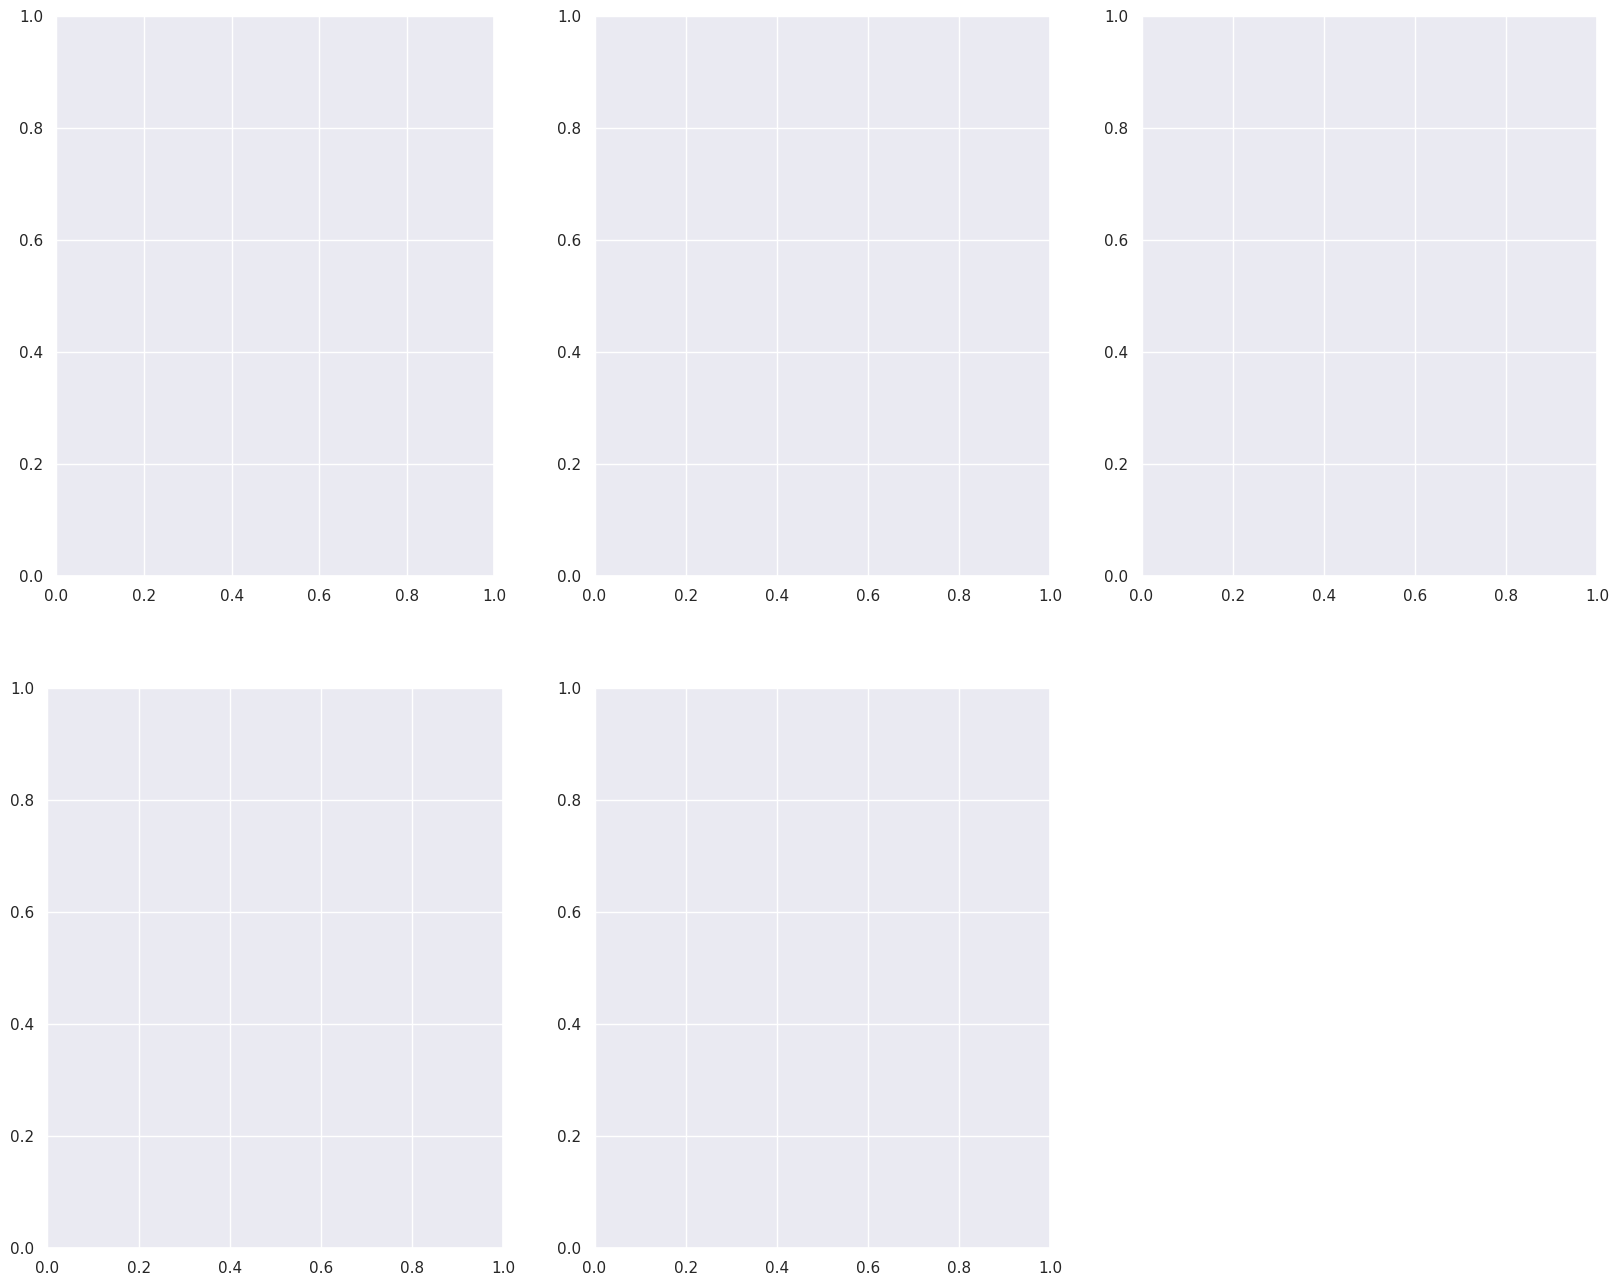

In [28]:
fig, axs = plt.subplots(2,3, figsize=(20,16))
ax = axs.flatten()
plt.axis('off')

for i, var_name in enumerate(sjoins):
    if i == 5:
        legend_display = True
    else:
        legend_display = False
    geo_data = sjoins[var_name]
    geo_data.plot(column=var_name[4:], cmap='Blues',legend = legend_display, ax=ax[i], vmax = 300000)
    # morocco_adm1[morocco_adm1['NAME_1'].isin(affected_adm1)].boundary.plot(ax=ax[id])
    # ax[i].set_title(column.replace('_', ' ').replace('mar', '').capitalize(), fontsize=12, ha='center')

    # text_to_add = eq_adm3[eq_adm3['PARAMVALUE']== eq_adm3['PARAMVALUE'].max()]['NAME_3'].iloc[0]
    # x, y =hrsl_morocco3[hrsl_morocco3['NAME_3']== text_to_add]['geometry'].iloc[0].centroid.x, hrsl_morocco3[hrsl_morocco3['NAME_3']== text_to_add]['geometry'].iloc[0].centroid.y

    # ax[id].scatter(x, y, c='red', marker='o', s=50, label=text_to_add)

    # ax[id].spines['top'].set_visible(False)
    # ax[id].spines['bottom'].set_visible(False)
    # ax[id].spines['right'].set_visible(False)
    # ax[id].spines['left'].set_visible(False)

    # ax[id].set_xticks([])
    # ax[id].set_yticks([])

## World Pop

WorldPop is based at the University of Southampton and maps populations across the globe. Since 2013, they have partnered with governments, UN agencies and donors to produce almost 45,000 datasets, complementing traditional population sources with dynamic, high-resolution data for mapping human population distributions, with the ultimate goal of ensuring that everyone, everywhere is counted in decision making.

Worldpop produces different population estimates, you will need to read [this guide](https://www.worldpop.org/choosing-the-right-worldpop-population-data-for-you/) to find which estimate is the right fit for your project. 

## Access the data
The data can be accessed from their [website](https://www.worldpop.org/)

<center><div>
    <img src="./images/worldpop.png" width="600"/>
</div></center>

There are several datasets available. In this example, we are downloading the population count
<center><div>
    <img src="./images/datasets.png" width="600"/>
</div></center>

This example uses the "Constrained individual countries 2020 (100m resolution)" dataset.  The constrained method uses extra layers that consider where settlements are placed, more information about the difference can be found [here](https://www.worldpop.org/methods/top_down_constrained_vs_unconstrained/) 

### Analyze the data

In [26]:
import rasterio #since the data is a geotiff
from rasterstats import zonal_stats
import matplotlib.pyplot as plt

In [27]:
dataset = rasterio.open('../data/tur_ppp_2020_constrained.tif')

In [28]:
band1 = dataset.read(1) #rasters can have several bands. In this case, there is only one

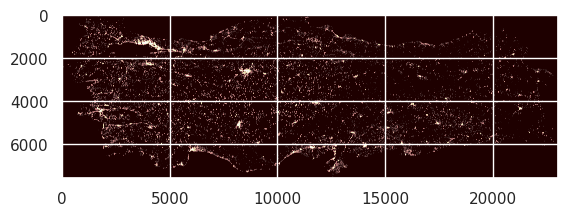

In [29]:
plt.imshow(band1, cmap='pink')

In [31]:
#Aggregate the raster information to a administrative level 2 boundaries using rasterstats
raster_path = '../data/tur_ppp_2020_constrained.tif'
stats = zonal_stats(adm2, raster_path, stats=['sum'])
adm2['population'] = pd.DataFrame(stats)['sum'].tolist()

In [52]:
#reproject adm2 to a projected CRS to calcualte area
adm2 = adm2.to_crs('EPSG:32635')
adm2['area'] = adm2.geometry.apply(lambda x: x.area/1000000)
adm2['popdensity_km2'] = adm2['population']/adm2['area']

In [53]:
m = adm2.explore(
    column="popdensity_km2",  # make choropleth based on "POP2010" column
    scheme="naturalbreaks",  # use mapclassify's natural breaks scheme
    legend=True,  # show legend
    k=10,  # use 10 bins
    tooltip=False,  # hide tooltip
    popup=["population", 'popdensity_km2', 'area'],  # show popup (on-click)
    legend_kwds=dict(colorbar=False),  # do not use colorbar
    name="pop",  # name of the layer in the map
)
m

## Practice
Now it is your turn. 

Using the presented datasources calculate population at administrative level 2 for your region of interest. 